## Описание файла 
Скрипт представляет собой инференс-решение для системы визуального поиска товаров, основанное на метрическом обучении с использованием Vision Transformer (DINOv2) и SubCenter ArcFace. Выполняет полный цикл: от очистки данных и обучения нейросети до построения FAISS-индекса и сохранения всех артефактов для быстрого инференса.

## Основные возможности

* **Подготовка данных**
  - Два режима очистки:
    * `preprocess_data()` – для train/val/test разделения: удаление полных дубликатов, конфликтующих меток (один phash в разных группах) и групп, содержащих менее 2 изображений.
    * `preprocess_all_data()` – для полного набора: удаление только дубликатов и конфликтов, сохранение одиночных изображений.
  - Разделение на выборки с сохранением целостности групп (`GroupShuffleSplit`).
  - Label Encoding идентификаторов групп.

* **Архитектура модели и функция потерь**
  - Бекбон: `vit_small_patch14_dinov2.lvd142m` (DINOv2) из `timm` с заморозкой всех слоёв, кроме последних 4 блоков трансформера.
  - Функция потерь: `SubCenterArcFaceLoss` с 3 подцентрами на класс для учёта внутриклассовой мультимодальности.

* **Обучение**
  - Раздельные скорости обучения: `4e-5` для размороженных слоёв бекбона, `4e-2` для проектора и параметров loss-функции.
  - Scheduler с линейным разогревом (2 эпохи) и косинусным затуханием.
  - Автоматическое сохранение лучшей модели по mAP@5 или последней эпохи (при обучении на всех данных).

* **Валидация и метрики поиска**
  - Оценка модели через метрики поиска: **Recall@1** и **mAP@5**.
  - **Similarity Gap** — разница между средним внутриклассовым и межклассовым косинусным сходством.
  - Сравнение кривых обучения с предыдущим Baseline.
  - Визуализация результатов поиска через `show_results()`.

* **Векторный поиск и инференс**
  - Построение FAISS-индекса (`IndexFlatIP`) на нормализованных эмбеддингах.
  - Сохранение `inference_index.faiss` и `inference_database.csv` для быстрого поиска похожих товаров.
  - Загрузка финальной модели (`inference_model.pth`) и готового индекса для дальнейшего использования.

## Результаты

После завершения обучения и оценки на тестовом наборе выводятся следующие метрики (примерные значения, зависят от разбиения):

- **Recall@1:** 0.8535
- **Recall@5:** 0.9220
- **Recall@10:** 0.9394
- **mAP@1:** 0.8535
- **mAP@5:** 0.8367
- **mAP@10:** 0.8420
- **Similarity Gap:** 0.6153

Точные значения могут незначительно отличаться при каждом запуске из-за фиксированного, но случайного разделения данных.

### Файлы

- `best_final_model.pth` – лучшая модель с валидации (по mAP@5).  
- `final_history.json` – история обучения (train loss и валидационные метрики).  
- `inference_model.pth` – модель, обученная на всех данных (для инференса).  
- `inference_index.faiss` – FAISS-индекс для быстрого поиска.  
- `inference_database.csv` – таблица изображений с путями, `label_group` и `label`.

### Инференс

Для поиска похожих товаров загрузите `inference_model.pth`, примените те же трансформации к новому изображению, извлеките эмбеддинг и используйте `inference_index.faiss` для поиска ближайших соседей.

## Установка и зависимости

Для работы скрипта требуются следующие библиотеки:
* `torch` и `torchvision`
* `timm` (модели компьютерного зрения)
* `pytorch_metric_learning` (реализация ArcFace)
* `faiss-cpu` или `faiss-gpu` (для векторного поиска)
* `albumentations` (продвинутые аугментации)
* `pandas`, `numpy`, `opencv-python`, `matplotlib`, `scikit-learn`, `tqdm`.

## Инструкция по использованию

1. **Пути к данным:** По умолчанию скрипт ищет данные в `/kaggle/input/competitions/shopee-product-matching/`. Если вы запускаете код локально, измените `BASE_DIR` в классе `Config`.
2. **Конфигурация:** Все ключевые параметры (размер изображения, гиперпараметры ArcFace, размер батча, seed, learning rate) сосредоточены в классе `Config` в начале скрипта.
3. **Запуск:** Запустите ячейки ноутбука последовательно. Для обучения скрипт сгенерирует отдельный файл `train_baseline.py` и запустит его, чтобы использовать все доступные видеокарты (DDP).

## Импорт библиотек и конфиг

In [1]:
import gc
import json
import os
import random
import sys
from typing import Dict, List, Optional, Tuple

import albumentations as A
import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from PIL import Image
from pytorch_metric_learning import losses
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [2]:
class Config:
    BASE_DIR = '/kaggle/input/competitions/shopee-product-matching/'
    CSV_PATH = f'{BASE_DIR}train.csv'
    IMAGE_DIR = f'{BASE_DIR}train_images/'
    DATASET_MEAN_COLOR = (192, 183, 178)  # mean-padding цвет
    IMG_SIZE = 336
    BATCH_SIZE = 128
    EPOCHS = 15
    BACK_LR = 4e-5
    PROJ_LR = 4e-2
    BACK_WEIGHT_DECAY = 1e-2
    PROJ_WEIGHT_DECAY = 1e-4
    ARC_MARGIN = 28.5
    ARC_SCALE = 32
    SEED = 42
    TRAIN_SIZE = 0.70
    VAL_SIZE   = 0.15
    TEST_SIZE  = 0.15
    NUM_WORKERS = 4    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Фиксируем источники случайности для воспроизводимости
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
A.core.composition.SEED = Config.SEED
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

## Функции и классы

In [4]:
def preprocess_data(
    csv_path: str,
    image_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int]:
    """
    Загружает и предобрабатывает данные Shopee.
    Этапы:
        1. Загрузка CSV и добавление полного пути к изображениям.
        2. Очистка данных:
           - удаление полных дубликатов (image_phash, label_group)
           - удаление строк с конфликтующими метками (один phash в разных группах)
           - удаление групп, в которых осталось менее 2 изображений
        3. Label Encoding для label_group.
        4. Разделение на train/val/test с сохранением целостности групп.
    """
    # Загрузка
    df = pd.read_csv(csv_path)
    df['image_path'] = df['image'].apply(lambda x: os.path.join(image_dir, x))
    
    # Очистка данных
    initial_len = len(df)
    # Удаляем точные дубликаты (одинаковые phash и группа)
    df = df.drop_duplicates(subset=['image_phash', 'label_group'], keep='first')
    print(f"Удалено полных дубликатов: {initial_len - len(df)}")
    
    # Удаляем конфликтующие записи: один phash, но разные группы
    tmp = df.groupby('image_phash')['label_group'].nunique()
    conflicting = tmp[tmp > 1].index
    if len(conflicting) > 0:
        pre_conf = len(df)
        df = df[~df['image_phash'].isin(conflicting)]
        print(f"Удалено конфликтующих записей: {pre_conf - len(df)}")
    else:
        print("Конфликтов не обнаружено.")
    
    # Удаляем группы, в которых меньше 2 изображений (нельзя обучить метрику)
    pre_single = len(df)
    group_counts = df['label_group'].value_counts()
    keep_groups = group_counts[group_counts >= 2].index
    df = df[df['label_group'].isin(keep_groups)].reset_index(drop=True)
    print(f"Удалено одиночных групп: {pre_single - len(df)}")
    print(f"Итоговый размер после очистки: {len(df)} (было {initial_len})")
    
    # Кодируем метки групп в целые числа
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label_group'])
    num_classes = df['label'].nunique()
    print(f"Уникальных групп товаров: {num_classes}")
    
    # Разделение на train/val/test с сохранением групп
    total = train_size + val_size + test_size
    assert abs(total - 1.0) < 1e-6, "Сумма долей должна быть 1.0"
    
    gss1 = GroupShuffleSplit(n_splits=1, test_size=val_size + test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(df, groups=df['label_group']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)
    
    test_frac = test_size / (val_size + test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=random_state)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['label_group']))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    
    print(f"Train: {len(train_df)} ({train_df['label_group'].nunique()} групп)")
    print(f"Val:   {len(val_df)} ({val_df['label_group'].nunique()} групп)")
    print(f"Test:  {len(test_df)} ({test_df['label_group'].nunique()} групп)")
    
    return train_df, val_df, test_df, num_classes

In [5]:
def preprocess_all_data(
    csv_path: str,
    image_dir: str
) -> Tuple[pd.DataFrame, int]:
    """
    Подготовка полного набора данных
    """
    df = pd.read_csv(csv_path)
    df['image_path'] = df['image'].apply(lambda x: os.path.join(image_dir, x))

    initial_len = len(df)
    # 1. Полные дубликаты
    df = df.drop_duplicates(subset=['image_phash', 'label_group'], keep='first')
    print(f"Удалено полных дубликатов: {initial_len - len(df)}")

    # 2. Конфликтующие phash
    tmp = df.groupby('image_phash')['label_group'].nunique()
    conflicting = tmp[tmp > 1].index
    if len(conflicting) > 0:
        pre_conf = len(df)
        df = df[~df['image_phash'].isin(conflicting)]
        print(f"Удалено конфликтующих записей: {pre_conf - len(df)}")
    else:
        print("Конфликтов не обнаружено.")

    print(f"Итоговый размер полного набора: {len(df)} (было {initial_len})")

    # Удаляем группы, в которых меньше 2 изображений (нельзя обучить метрику)
    pre_single = len(df)
    group_counts = df['label_group'].value_counts()
    keep_groups = group_counts[group_counts >= 2].index
    df = df[df['label_group'].isin(keep_groups)].reset_index(drop=True)
    print(f"Удалено одиночных групп: {pre_single - len(df)}")
    print(f"Итоговый размер после очистки: {len(df)} (было {initial_len})")

    # Кодирование меток
    le_full = LabelEncoder()
    df['label'] = le_full.fit_transform(df['label_group'])
    num_classes_full = df['label'].nunique()
    print(f"Уникальных групп товаров: {num_classes_full}")

    return df, num_classes_full

In [6]:
class ShopeeDataset(Dataset):
    """PyTorch Dataset для загрузки изображений с применением аугментаций."""
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

In [7]:
def get_embeddings(
    model: nn.Module,
    loader: DataLoader
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Извлекает L2-нормализованные эмбеддинги для всех объектов из loader, используя переданную модель
    """
    model.eval()
    device = next(model.parameters()).device # Устройство, на котором находится модель
    all_embs, all_labels = [], []
    # Определяем, нужно ли показывать прогресс-бар
    with torch.inference_mode():
        # Добавляем file=sys.stdout, чтобы синхронизировать вывод с обычным print
        with tqdm(loader, desc="Embed", leave=False, file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(device, non_blocking=True)
                # Используем автоматическое смешанное точное вычисление (AMP) с bfloat16
                if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        feats = model(images)
                else:
                    feats = model(images)
                # Нормализуем эмбеддинги к единичной L2-норме
                feats = F.normalize(feats.float(), p=2, dim=1)
                # Перемещаем результат на CPU и добавляем в список
                all_embs.append(feats.cpu())
                all_labels.append(labels)
    # Конкатенируем все части в единые тензоры
    embs = torch.cat(all_embs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return embs, labels

In [8]:
def compute_gap_slow(
    embs_norm: np.ndarray,
    labels: np.ndarray
) -> float:
    """
    Вычисляет разность между средним внутриклассовым и средним межклассовым косинусным
    сходством для нормализованных эмбеддингов. Медленный CPU‑вариант для запасного случая.
    """
    n = embs_norm.shape[0]
    sim = embs_norm @ embs_norm.T
    intra_sim = []
    inter_sim = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra_sim.append(sim[i, j])
            else:
                inter_sim.append(sim[i, j])
    mean_intra = np.mean(intra_sim) if intra_sim else 0.0
    mean_inter = np.mean(inter_sim) if inter_sim else 0.0
    return mean_intra - mean_inter

In [9]:
def fast_similarity_gap_gpu(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    batch_size: int = 2048,
) -> float:
    """
    Быстрый расчёт разницы между средним внутриклассовым и межклассовым
    косинусным сходством на GPU. При невозможности – автоматический откат на CPU.
    """
    if not torch.cuda.is_available():
        return compute_gap_slow(embs_norm, labels)

    device = torch.device('cuda')
    try:
        embs = torch.from_numpy(embs_norm).to(device)
        lbls = torch.from_numpy(labels).to(device)
        n = embs.shape[0]
        intra_sum, inter_sum = 0.0, 0.0
        intra_cnt, inter_cnt = 0, 0
        for i in range(0, n, batch_size):
            batch_embs = embs[i : i + batch_size]
            batch_lbls = lbls[i : i + batch_size]
            # Матрица сходства [batch_size, n]
            sim = batch_embs @ embs.T
            # Маска совпадения классов
            is_same = (batch_lbls.view(-1, 1) == lbls.view(1, -1))
            # Индексы диагональных элементов в текущем батче
            diag_idx = torch.arange(i, min(i + batch_size, n), device=device)
            local_idx = torch.arange(len(batch_lbls), device=device)
            # Исключаем самосравнение (диагональ)
            is_same[local_idx, diag_idx] = False
            is_diff = ~is_same
            is_diff[local_idx, diag_idx] = False   # тоже убираем диагональ
            # Суммируем внутри- и межклассовые сходства
            intra_sum += sim[is_same].sum().item()
            intra_cnt += is_same.sum().item()
            inter_sum += sim[is_diff].sum().item()
            inter_cnt += is_diff.sum().item()
        intra_mean = intra_sum / intra_cnt if intra_cnt > 0 else 0.0
        inter_mean = inter_sum / inter_cnt if inter_cnt > 0 else 0.0
        return intra_mean - inter_mean
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            return compute_gap_slow(embs_norm, labels)
        raise e

In [10]:
def compute_metrics_from_embeddings(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    recall_ks: List[int] = [1, 5, 10],
    map_ks: List[int] = [1, 5, 10]
) -> Dict[str, float]:
    """Вычисляет метрики качества эмбеддингов: Recall@k и mAP@k, используя FAISS"""
    # Создаём FAISS-индекс для поиска по внутреннему произведению.
    n, d = embs_norm.shape
    index = faiss.IndexFlatIP(d)
    index.add(embs_norm)
    # Ищем для каждого образца max_k ближайших соседей.
    max_k = max(max(recall_ks), max(map_ks)) + 1
    _, I = index.search(embs_norm, max_k)
    metrics = {}
    # Подсчёт Recall@k
    for k in recall_ks:
        retrieved = labels[I[:, 1:k+1]] # индекс 0 – это сам запрос
        # Проверяем, есть ли среди этих k соседей хотя бы один с тем же классом, что у запроса
        hits = np.any(retrieved == labels[:, None], axis=1).sum()
        metrics[f'recall@{k}'] = hits / n
    # Подсчёт mAP@k
    for k in map_ks:
        retrieved = labels[I[:, 1:k+1]]  # индекс 0 – это сам запрос
        # Маска релевантности: True там, где метка соседа совпадает с меткой запроса
        relevant = (retrieved == labels[:, None])
        # Precision на каждом ранге: кумулятивная сумма релевантных, делённая на номер позиции
        prec = relevant.cumsum(axis=1) / np.arange(1, k+1)
        total_rel_all = np.bincount(labels)[labels] - 1
        total_rel = np.minimum(k, total_rel_all)
        # Average Precision для каждого запроса: сумма (precision * relevant) / total_rel
        ap = (prec * relevant).sum(axis=1) / np.maximum(total_rel, 1)
        # Mean Average Precision – среднее по всем запросам
        metrics[f'map@{k}'] = float(np.mean(ap))
    # Similarity Gap
    metrics['gap'] = fast_similarity_gap_gpu(embs_norm, labels)
    return metrics

In [11]:
def show_results(
    query_idx: int,
    test_df: pd.DataFrame,
    test_embs: np.ndarray,
    test_labels: np.ndarray,
    faiss_index: faiss.Index,
    k: int = 5
) -> None:
    """
    Отображает запрос и k ближайших соседей. Зелёная рамка – тот же класс, красная – другой.
    """
    query_emb = test_embs[query_idx:query_idx+1]
    query_label = test_labels[query_idx]
    query_img_path = test_df.iloc[query_idx]['image_path']

    D, I = faiss_index.search(query_emb, k+1)
    neighbors = I[0][1:] # пропускаем самого себя

    fig, axes = plt.subplots(1, k+1, figsize=(15, 5))
    img = Image.open(query_img_path)
    axes[0].imshow(img)
    axes[0].set_title(f"Запрос\nГруппа: {query_label}")
    axes[0].axis('off')

    for j, ni in enumerate(neighbors):
        neighbor_label = test_labels[ni]
        neighbor_path = test_df.iloc[ni]['image_path']
        img = Image.open(neighbor_path)
        color = 'green' if neighbor_label == query_label else 'red'
        axes[j+1].imshow(img)
        axes[j+1].set_title(f"Сосед {j+1}\nГруппа: {neighbor_label}", color=color)
        axes[j+1].axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
class DinoWithProjectorUnfrozen(nn.Module):
    """DINOv2 ViT-S/14 с обучаемым проектором и возможностью частичной разморозки последних блоков."""
    def __init__(self, img_size=336, proj_dim=384, unfreeze_blocks=4):
        super().__init__()
        self.backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m', 
                                          pretrained=True, num_classes=0, img_size=img_size)
        # Заморозка бекбона
        for p in self.backbone.parameters():
            p.requires_grad = False
        # Разморозка последних unfreeze_blocks блоков
        if unfreeze_blocks > 0:
            for block in self.backbone.blocks[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True
        self.proj = nn.Sequential(
            nn.Linear(384, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, x):
        return self.proj(self.backbone(x))

## Trainer

In [13]:
class Trainer:
    """Управляет обучением и валидацией модели (без DDP)."""
    def __init__(
        self,
        model: torch.nn.Module,
        loss_func: losses.SubCenterArcFaceLoss,
        optimizer: torch.optim.Optimizer,
        scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None
    ):
        self.model = model
        self.loss_func = loss_func
        self.device = Config.DEVICE
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

        self.best_map = 0.0
        self.history = {
            'train_loss': [],
            'val_recall1': [],
            'val_map5': [],
            'val_gap': []
        }

    def _run_batch(self, images: torch.Tensor, labels: torch.Tensor) -> float:
        """Обрабатывает один батч: прямой проход, вычисление потерь, обратное распространение и шаг оптимизатора."""
        self.optimizer.zero_grad()
        if self.scaler is not None:
            with torch.amp.autocast('cuda'):
                emb = self.model(images)
                loss = self.loss_func(emb, labels)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            emb = self.model(images)
            loss = self.loss_func(emb, labels)
            loss.backward()
            self.optimizer.step()
        return loss.item()

    def _run_epoch(self, epoch: int) -> None:
        """Выполняет одну эпоху обучения."""
        self.model.train()
        total_loss = 0.0
        with tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.epochs}", file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                loss_val = self._run_batch(images, labels)
                total_loss += loss_val
                pbar.set_postfix({'loss': f'{loss_val:.4f}'})
        avg_loss = total_loss / len(self.train_loader)
        self.history['train_loss'].append(avg_loss)
        print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}", flush=True)

    def validate(self, epoch: int) -> None:
        """Выполняет валидацию модели."""
        self.model.eval()
        val_embs, val_labels = get_embeddings(self.model, self.val_loader)

        metrics = compute_metrics_from_embeddings(val_embs, val_labels, recall_ks=[1], map_ks=[5])
        val_recall1 = metrics['recall@1']
        val_map5 = metrics['map@5']
        gap = metrics['gap']

        self.history['val_recall1'].append(val_recall1)
        self.history['val_map5'].append(val_map5)
        self.history['val_gap'].append(gap)
        print(f"Epoch {epoch+1} | Val mAP@5: {val_map5:.4f} | Val Recall@1: {val_recall1:.4f} | Val Gap: {gap:.4f}")

    def _check_improvement(self, epoch: int) -> bool:
        """
        Проверяет улучшение валидационной метрики, сохраняет модель при необходимости
        и возвращает True, если нужно остановить обучение (ранняя остановка).
        """
        current_map5 = self.history['val_map5'][-1]
        if current_map5 > self.best_map:
            self.best_map = current_map5
            self.epochs_without_improvement = 0
            torch.save(self.model.state_dict(), "best_final_model.pth")
            print(f"   Новая лучшая модель сохранена (mAP@5 = {self.best_map:.4f})")
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                print(f"Ранняя остановка на эпохе {epoch+1} (нет улучшений {self.patience} эпох)")
                return True
        return False

    def train(self, max_epochs: int, train_loader: DataLoader, val_loader: Optional[DataLoader] = None, patience: int = 3) -> None:
        """Главный цикл обучения."""
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = max_epochs
        self.patience = patience
        self.epochs_without_improvement = 0
    
        for epoch in range(self.epochs):
            self._run_epoch(epoch)
            if val_loader is not None:
                self.validate(epoch)
                if self._check_improvement(epoch):
                    break
            if self.scheduler is not None:
                self.scheduler.step()
        if val_loader is None:
            torch.save(self.model.state_dict(), "inference_model.pth")
            print("Модель сохранена (inference_model.pth)")

    def save_history(self) -> None:
        """Сохраняет историю метрик обучения в JSON-файл."""
        n = len(self.history['train_loss'])
        info = {
            'epoch': list(range(1, n + 1)),
            'train_loss': self.history['train_loss'],
        }
        if self.val_loader is not None:
            info['val_recall1'] = self.history['val_recall1']
            info['val_map5'] = self.history['val_map5']
            info['val_gap'] = self.history['val_gap']
            info['best_map'] = self.best_map
        with open('final_history.json', 'w') as f:
            json.dump(info, f, indent=2)

## Подготовка данных

In [14]:
# Аугментации для обучения
train_transforms = A.Compose([
        A.RandomScale(scale_limit=(-0.3, 0), p=1.0),
        A.LongestMaxSize(max_size=Config.IMG_SIZE),              
        A.PadIfNeeded(min_height=Config.IMG_SIZE, min_width=Config.IMG_SIZE, 
                      border_mode=cv2.BORDER_CONSTANT, fill=Config.DATASET_MEAN_COLOR, position='random'),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        A.CoarseDropout(num_holes_range=(1, 1), hole_height_range=(0.1, 0.2),
                        hole_width_range=(0.1, 0.2), fill = Config.DATASET_MEAN_COLOR, p=0.3),
        A.Normalize(),
        ToTensorV2()
    ])

# Валидационные/тестовые трансформации: только приведение размера и нормализация
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=Config.IMG_SIZE),
    A.PadIfNeeded(Config.IMG_SIZE, Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill = Config.DATASET_MEAN_COLOR),
    A.Normalize(),
    ToTensorV2()
])

In [15]:
train_df, val_df, test_df, num_classes = preprocess_data(
    csv_path=Config.CSV_PATH,
    image_dir=Config.IMAGE_DIR,
    train_size=Config.TRAIN_SIZE,
    val_size=Config.VAL_SIZE,
    test_size=Config.TEST_SIZE,
    random_state=Config.SEED
)

Удалено полных дубликатов: 5358
Удалено конфликтующих записей: 304
Удалено одиночных групп: 1090
Итоговый размер после очистки: 27498 (было 34250)
Уникальных групп товаров: 9901
Train: 19411 (6930 групп)
Val:   4113 (1485 групп)
Test:  3974 (1486 групп)


In [16]:
train_dataset = ShopeeDataset(train_df, train_transforms)
val_dataset = ShopeeDataset(val_df, val_transforms)
test_dataset = ShopeeDataset(test_df, val_transforms)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True, persistent_workers=(Config.NUM_WORKERS > 0))
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True, persistent_workers=(Config.NUM_WORKERS > 0))
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

In [18]:
all_df, all_num_classes = preprocess_all_data(Config.CSV_PATH, Config.IMAGE_DIR)

Удалено полных дубликатов: 5358
Удалено конфликтующих записей: 304
Итоговый размер полного набора: 28588 (было 34250)
Удалено одиночных групп: 1090
Итоговый размер после очистки: 27498 (было 34250)
Уникальных групп товаров: 9901


In [19]:
all_dataset = ShopeeDataset(all_df, transforms=train_transforms)
all_loader = DataLoader(all_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True, persistent_workers=(Config.NUM_WORKERS > 0))
all_dataset_for_faiss = ShopeeDataset(all_df, transforms=val_transforms)
all_loader_for_faiss = DataLoader(all_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

## Обучение

In [20]:
# Модель и лосс
model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

loss_func = losses.ArcFaceLoss(
    num_classes=num_classes,
    embedding_size=384,
    margin=Config.ARC_MARGIN,
    scale = Config.ARC_SCALE,
).to(Config.DEVICE)

# Оптимизатор
unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {'params': unfrozen_backbone_params, 'lr': Config.BACK_LR,       'weight_decay': Config.BACK_WEIGHT_DECAY},
    {'params': model.proj.parameters(),  'lr': Config.PROJ_LR,       'weight_decay': Config.PROJ_WEIGHT_DECAY},
    {'params': loss_func.parameters(),   'lr': Config.PROJ_LR,       'weight_decay': 0.0}])

# Scheduler
warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=3)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS-3, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, scheduler=scheduler)

trainer.train(Config.EPOCHS, train_loader, val_loader)
trainer.save_history()

del model, loss_func, optimizer, trainer
gc.collect()
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Epoch 1/15: 100%|██████████| 152/152 [02:35<00:00,  1.03s/it, loss=25.5959]
Epoch 1 | Train Loss: 25.6907
Epoch 1 | Val mAP@5: 0.7485 | Val Recall@1: 0.7785 | Val Gap: 0.6599
   Новая лучшая модель сохранена (mAP@5 = 0.7485)
Epoch 2/15: 100%|██████████| 152/152 [02:02<00:00,  1.24it/s, loss=20.1958]
Epoch 2 | Train Loss: 21.8100
Epoch 2 | Val mAP@5: 0.7979 | Val Recall@1: 0.8191 | Val Gap: 0.6863
   Новая лучшая модель сохранена (mAP@5 = 0.7979)
Epoch 3/15: 100%|██████████| 152/152 [02:04<00:00,  1.22it/s, loss=15.6616]
Epoch 3 | Train Loss: 16.3340
Epoch 3 | Val mAP@5: 0.8206 | Val Recall@1: 0.8393 | Val Gap: 0.6380
   Новая лучшая модель сохранена (mAP@5 = 0.8206)
Epoch 4/15: 100%|██████████| 152/152 [02:02<00:00,  1.24it/s, loss=11.0397]
Epoch 4 | Train Loss: 10.8884
Epoch 4 | Val mAP@5: 0.8255 | Val Recall@1: 0.8410 | Val Gap: 0.6142
   Новая лучшая модель сохранена (mAP@5 = 0.8255)
Epoch 5/15: 100%|██████████| 152/152 [02:02<00:00,  1.24it/s, loss=5.7615]
Epoch 5 | Train Loss: 6.0

## Оценка обученной модели

In [21]:
# Загружаем историю обучения
with open('final_history.json', 'r') as f:
    history = json.load(f)

base = None
# Загружаем историю обучения baseline
if os.path.exists ('/kaggle/input/datasets/aidar67/baseline-history/baseline_history.json'):
    with open('/kaggle/input/datasets/aidar67/baseline-history/baseline_history.json', 'r') as f:
        base = json.load(f)

# Загружаем лучшую модель (она сохранена в /kaggle/working/ или текущей директории)
model = DinoWithProjectorUnfrozen(unfreeze_blocks=4)
model.load_state_dict(torch.load("best_final_model.pth"))
model.to(Config.DEVICE)
model.eval()
print("Модель загружена и готова к оценке.")

Модель загружена и готова к оценке.


In [22]:
# Получаем эмбеддинги для теста
test_embs, test_labels = get_embeddings(model, test_loader)

# Считаем метрики
test_metrics = compute_metrics_from_embeddings(test_embs, test_labels)

In [23]:
print("\n--- Тестовые метрики ---")
for k in [1,5,10]:
    print(f"Recall@{k}: {test_metrics[f'recall@{k}']:.4f}")
for k in [1,5,10]:
    print(f"mAP@{k}: {test_metrics[f'map@{k}']:.4f}")
print(f"Similarity Gap: {test_metrics['gap']:.4f}")


--- Тестовые метрики ---
Recall@1: 0.8535
Recall@5: 0.9220
Recall@10: 0.9394
mAP@1: 0.8535
mAP@5: 0.8367
mAP@10: 0.8420
Similarity Gap: 0.6153


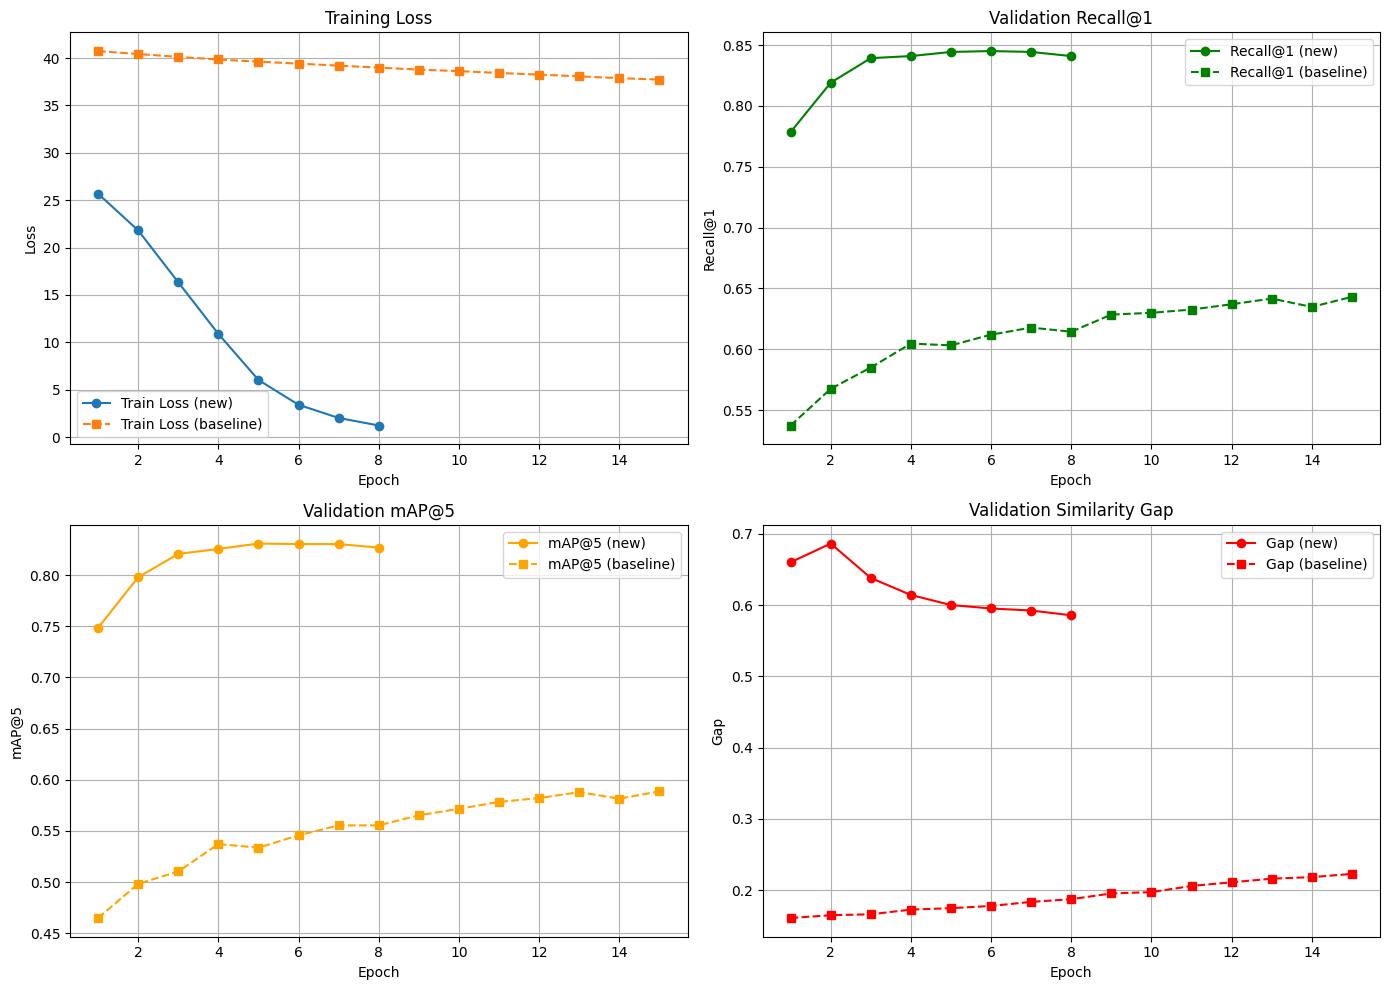

In [24]:
# ==================== Графики обучения ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# final
axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train Loss (new)')
axes[1].plot(history['epoch'], history.get('val_recall1', []), marker='o', color='green', label='Recall@1 (new)')
axes[2].plot(history['epoch'], history.get('val_map5', []), marker='o', color='orange', label='mAP@5 (new)')
axes[3].plot(history['epoch'], history.get('val_gap', []), marker='o', color='red', label='Gap (new)')

# baseline 
if base is not None:
    axes[0].plot(base['epoch'], base['train_loss'], marker='s', linestyle='--', label='Train Loss (baseline)')
    axes[1].plot(base['epoch'], base.get('val_recall1', []), marker='s', linestyle='--', color='green', label='Recall@1 (baseline)')
    axes[2].plot(base['epoch'], base.get('val_map5', []), marker='s', linestyle='--', color='orange', label='mAP@5 (baseline)')
    axes[3].plot(base['epoch'], base.get('val_gap', []), marker='s', linestyle='--', color='red', label='Gap (baseline)')

titles = ['Training Loss', 'Validation Recall@1', 'Validation mAP@5', 'Validation Similarity Gap']
ylabels = ['Loss', 'Recall@1', 'mAP@5', 'Gap']
for i, ax in enumerate(axes):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

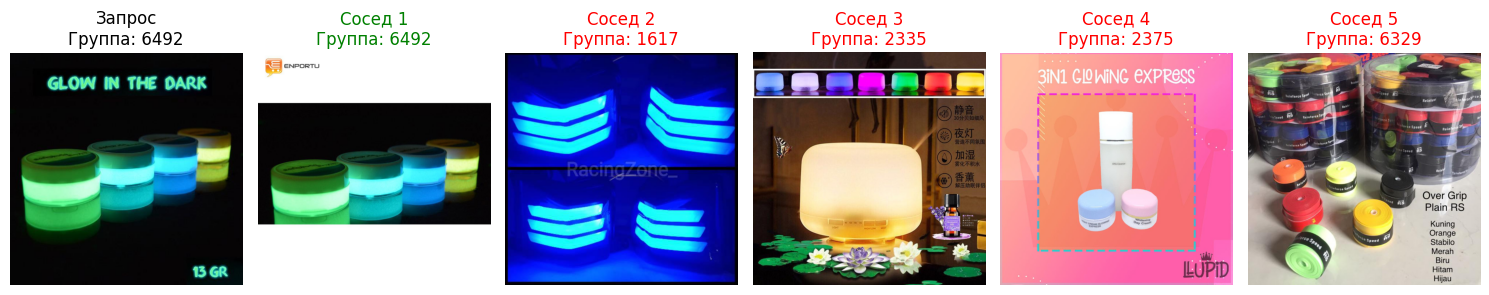

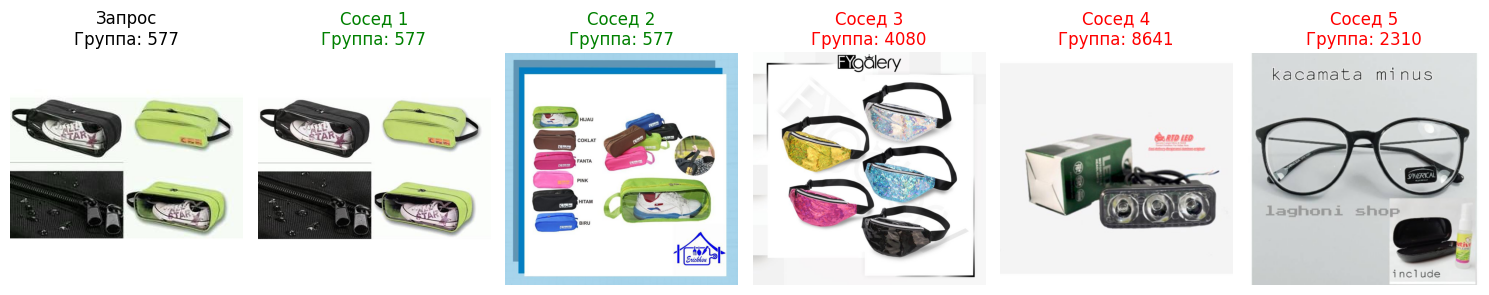

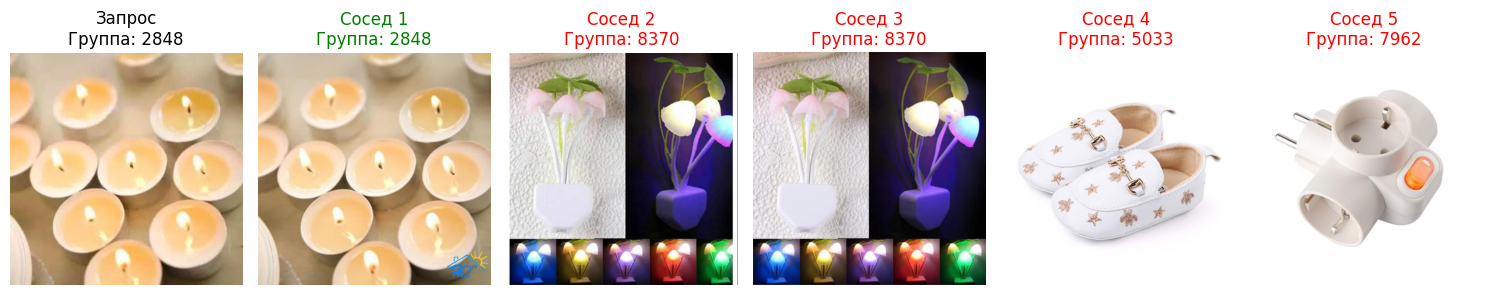

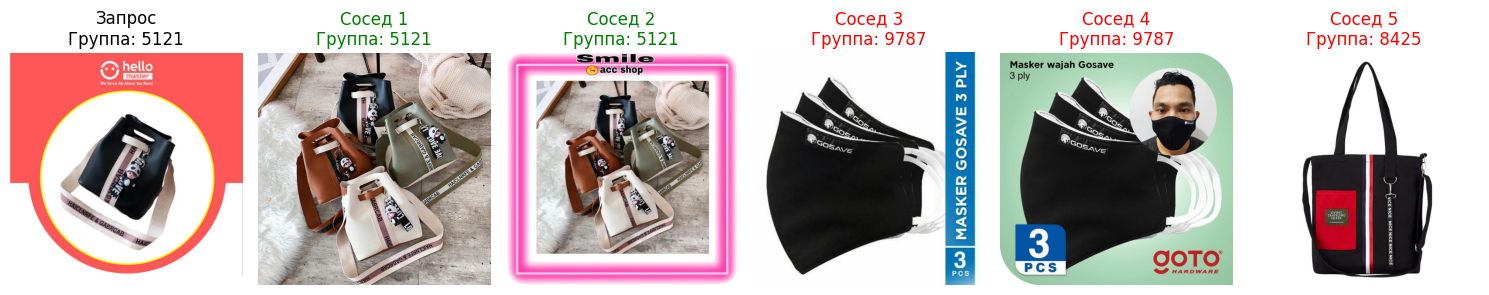

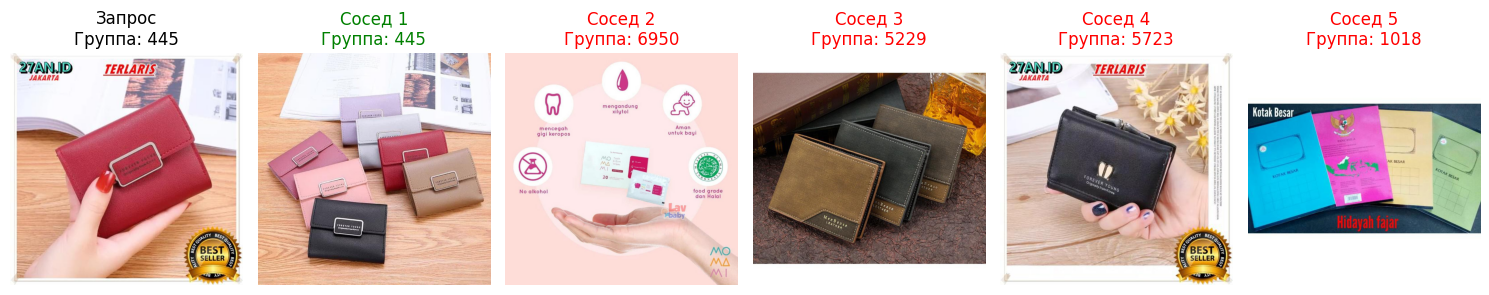

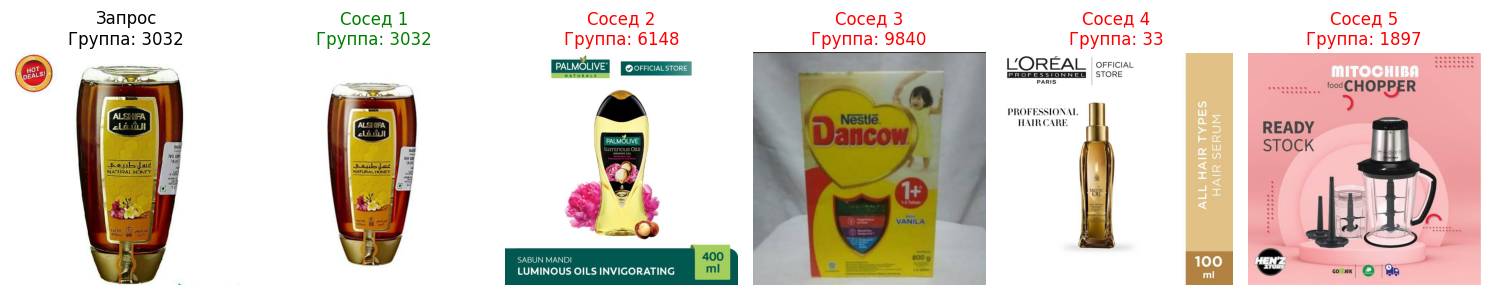

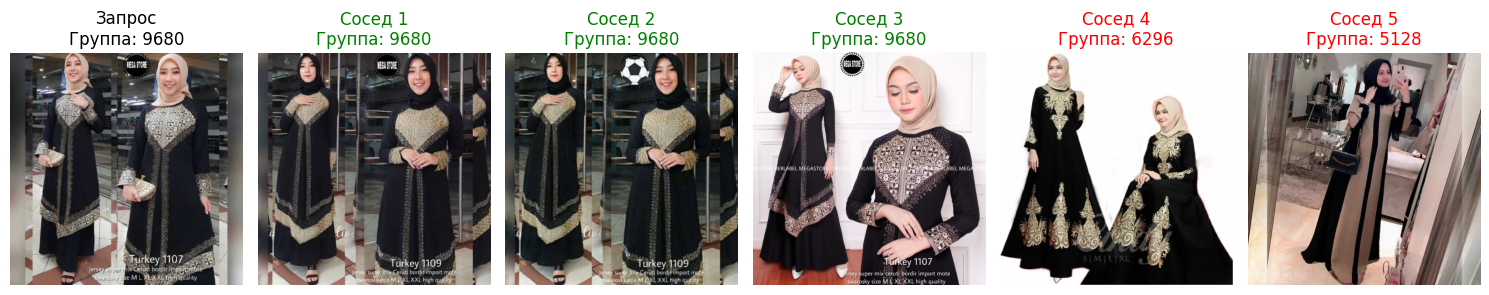

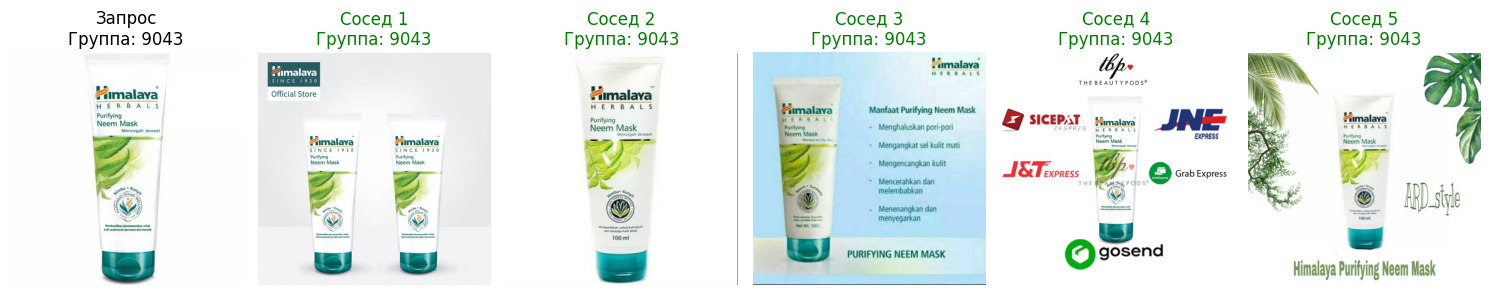

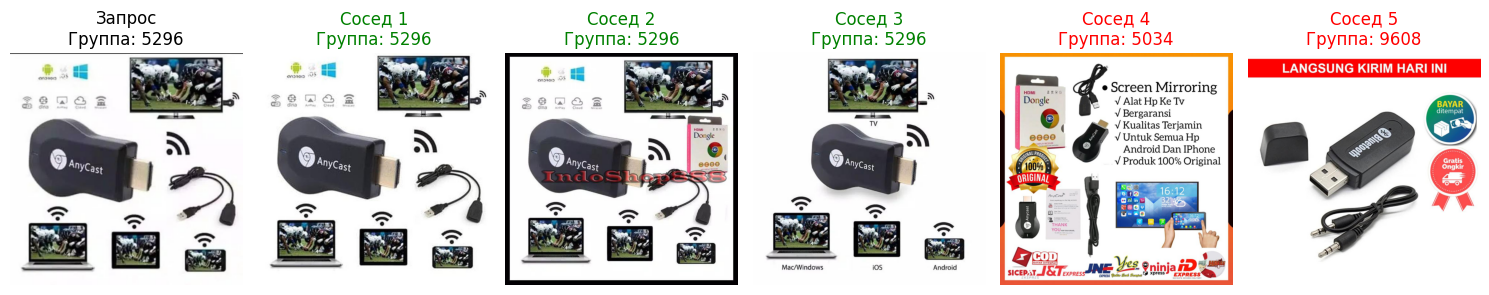

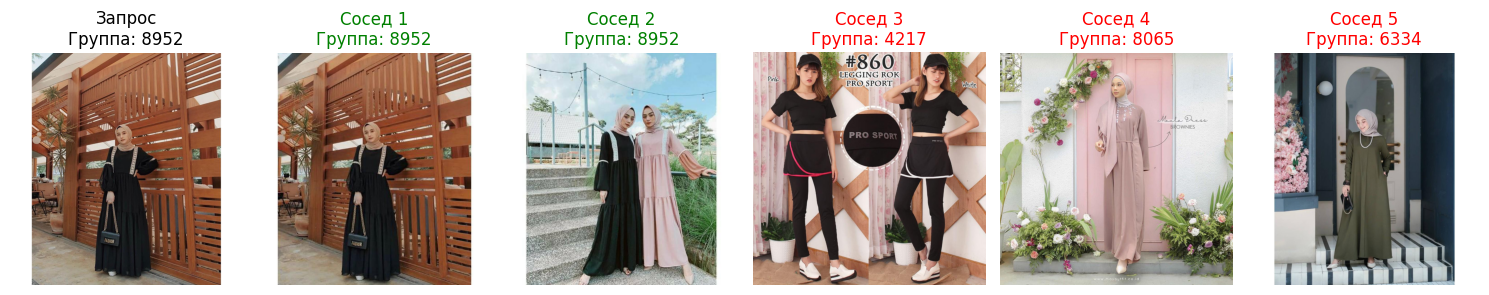

In [25]:
# Строим FAISS индекс для теста
faiss_index = faiss.IndexFlatIP(test_embs.shape[1])
faiss_index.add(test_embs)

# Показываем несколько случайных примеров поиска
for _ in range(10):
    idx = random.randint(0, len(test_df)-1)
    show_results(idx, test_df, test_embs, test_labels, faiss_index)

## Обучение модели на всех данных

In [26]:
if 'val_map5' in history and len(history['val_map5']) > 0:
    best_epoch = history['epoch'][max(range(len(history['val_map5'])), key=lambda i: history['val_map5'][i])]
    print(f"Лучшая эпоха по mAP@5: {best_epoch}")
else:
    best_epoch = Config.EPOCHS  # fallback, если валидации не было
    print("Валидационных метрик не найдено, используем Config.EPOCHS")

Лучшая эпоха по mAP@5: 5


In [27]:
# Модель и лосс
model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

loss_func = losses.ArcFaceLoss(
    num_classes=all_num_classes,
    embedding_size=384,
    margin=Config.ARC_MARGIN,
    scale = Config.ARC_SCALE,
).to(Config.DEVICE)

# Оптимизатор
unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {'params': unfrozen_backbone_params, 'lr': Config.BACK_LR,       'weight_decay': Config.BACK_WEIGHT_DECAY},
    {'params': model.proj.parameters(),  'lr': Config.PROJ_LR,       'weight_decay': Config.PROJ_WEIGHT_DECAY},
    {'params': loss_func.parameters(),   'lr': Config.PROJ_LR,       'weight_decay': 0.0}])

# Scheduler
warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=3)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = Config.EPOCHS - 3, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, scheduler=scheduler)

trainer.train(best_epoch , all_loader) # best_epoch - эпоха на которой final_model с наибольшим mAP@5 на валидации
trainer.save_history()

del model, loss_func, optimizer, trainer
gc.collect()
torch.cuda.empty_cache()

Epoch 1/5: 100%|██████████| 215/215 [03:00<00:00,  1.19it/s, loss=25.3853]
Epoch 1 | Train Loss: 25.6663
Epoch 2/5: 100%|██████████| 215/215 [02:52<00:00,  1.24it/s, loss=20.1989]
Epoch 2 | Train Loss: 22.1864
Epoch 3/5: 100%|██████████| 215/215 [02:50<00:00,  1.26it/s, loss=16.1769]
Epoch 3 | Train Loss: 16.7041
Epoch 4/5: 100%|██████████| 215/215 [02:47<00:00,  1.28it/s, loss=8.6060] 
Epoch 4 | Train Loss: 11.2117
Epoch 5/5: 100%|██████████| 215/215 [02:47<00:00,  1.29it/s, loss=7.6876]
Epoch 5 | Train Loss: 6.4218
Модель сохранена (inference_model.pth)


## FAISS индекс

In [28]:
model = DinoWithProjectorUnfrozen(unfreeze_blocks=4)
model.load_state_dict(torch.load("inference_model.pth"))
model.to(Config.DEVICE)
model.eval()

# Построение и сохранение FAISS-индекса 
all_embs, all_labels = get_embeddings(model, all_loader_for_faiss)
faiss_index = faiss.IndexFlatIP(all_embs.shape[1])
faiss_index.add(all_embs)
faiss.write_index(faiss_index, "inference_index.faiss")
print("FAISS-индекс сохранён в inference_index.faiss")

# Сохранение базы данных
all_df[['image', 'label_group', 'label']].to_csv("inference_database.csv", index=False)
print("База данных сохранена в inference_database.csv")

FAISS-индекс сохранён в inference_index.faiss           
База данных сохранена в inference_database.csv
